In [79]:
import json
metadata = {
    "0": {
        "string": "cardano"
    },
    "1": {
        "int": 14
    },
    "2": {
        "bytes": "0x2512a00e9653fe49a44a5886202e24d77eeb998f"
    },
    "3": {
        "list": [
            {
                "string": "test"
            }
        ]
    },
    "4": {
        "map": [
            {
                "k": {
                    "string": "key"
                },
                "v": {
                    "string": "value"
                }
            }
        ]
    }
}


{'0': 'cardano',
 '1': 14,
 '2': [53, 23, 53, 64, 23, 6],
 '3': ['test1', 10, [37, 18, 160, 14, 150]],
 '4': {'key': 'value',
  'num_val': 100,
  2: 'number as key',
  'bytes_val': [37, 18, 160, 14, 150]}}

In [101]:
import os
import io
import PIL
from matplotlib.pyplot import imshow
import numpy as np
from itertools import islice

def chunk(it, size):
    it = iter(it)
    while slice := tuple(islice(it, size)):
        yield slice
        
def image2hex(path):
    with open(path, "rb") as f:
        return list(bytearray(f.read()))
       
numbers = image2hex(icon)
chunks = [list(c) for c in chunk(numbers, 64)]


In [117]:
js = {
    "0": "cardano", 
    "1": 14, 
    "2": [53, 23, 53, 64, 23, 6],
    "3": ["test1",10,[37, 18, 160, 14, 150]],
    "4": { 
        "key":"value",
        "num_val":100, 
        2:'number as key',
        'bytes_val':[37, 18, 160, 14, 150] 
    },
    "5": { "image": chunks, "data": [ 3,4 ] },
    "6": "125",
    "7" : "long string hello world long string hello world long string hello world"
}
js

{'0': 'cardano',
 '1': 14,
 '2': [53, 23, 53, 64, 23, 6],
 '3': ['test1', 10, [37, 18, 160, 14, 150]],
 '4': {'key': 'value',
  'num_val': 100,
  2: 'number as key',
  'bytes_val': [37, 18, 160, 14, 150]},
 '5': {'image': [[137,
    80,
    78,
    71,
    13,
    10,
    26,
    10,
    0,
    0,
    0,
    13,
    73,
    72,
    68,
    82,
    0,
    0,
    0,
    24,
    0,
    0,
    0,
    24,
    8,
    6,
    0,
    0,
    0,
    224,
    119,
    61,
    248,
    0,
    0,
    0,
    6,
    98,
    75,
    71,
    68,
    0,
    255,
    0,
    255,
    0,
    255,
    160,
    189,
    167,
    147,
    0,
    0,
    0,
    137,
    73,
    68,
    65,
    84,
    72,
    137,
    237,
    149,
    193],
   [9,
    128,
    48,
    12,
    69,
    159,
    226,
    10,
    130,
    75,
    184,
    135,
    197,
    153,
    117,
    13,
    239,
    173,
    123,
    212,
    131,
    246,
    164,
    13,
    154,
    8,
    34,
    250,
    32,
    148,
    150,
    54,
 

In [126]:
def is_number(v):
    if type(v)==int:
        return True
    if type(v)==str:
        if v[0] in ('-', '+'):
             return v[1:].isdigit()
        else:
            return v.isdigit()
    return False

def val2obj(v):
    if is_number(v): 
        return { 'int': int(v) }
    if type(v)==str: 
        if len(v)>64:
            v = val2obj([''.join(c) for c in chunk(word, 64)])
        return { 'string': v }
    if type(v)==dict: 
        d = []
        for key,val in v.items():
            map={}
            map['k'] = val2obj(key)
            map['v'] = val2obj(val)
            d.append(map)
        return { 'map': d }
    if type(v) == list: 
        d = []
        isbytes = all(isinstance(i, int) for i in v)
        if isbytes:
            return { 'bytes' : '0x' + bytearray(v).hex() }
        for i in v:
            d.append(val2obj(i))
        return { 'list': d }
        
def js_meta(js):
    meta = {}
    for k,v in js.items():
        meta[k] = val2obj(v)
    return meta
meta = js_meta(js)
print(json.dumps(meta, indent=4))

{
    "0": {
        "string": "cardano"
    },
    "1": {
        "int": 14
    },
    "2": {
        "bytes": "0x351735401706"
    },
    "3": {
        "list": [
            {
                "string": "test1"
            },
            {
                "int": 10
            },
            {
                "bytes": "0x2512a00e96"
            }
        ]
    },
    "4": {
        "map": [
            {
                "k": {
                    "string": "key"
                },
                "v": {
                    "string": "value"
                }
            },
            {
                "k": {
                    "string": "num_val"
                },
                "v": {
                    "int": 100
                }
            },
            {
                "k": {
                    "int": 2
                },
                "v": {
                    "string": "number as key"
                }
            },
            {
                "k": {
           

In [127]:
word = "long string hello world long string hello world long string hello world"
[''.join(c) for c in chunk(word, 64)]

['long string hello world long string hello world long string hell', 'o world']

In [128]:
icon = r"C:\Users\San\Downloads\calendar.png"
num = [53, 23, 53, 64, 23, 6]
bytearray(num).hex()
h = '0x2512a00e96'
n = list(bytearray.fromhex(h[2:]))
n

[37, 18, 160, 14, 150]

[137, 80, 78, 71, 13, 10, 26, 10, 0, 0, 0, 13, 73, 72, 68, 82, 0, 0, 0, 24, 0, 0, 0, 24, 8, 6, 0, 0, 0, 224, 119, 61, 248, 0, 0, 0, 6, 98, 75, 71, 68, 0, 255, 0, 255, 0, 255, 160, 189, 167, 147, 0, 0, 0, 137, 73, 68, 65, 84, 72, 137, 237, 149, 193, 9, 128, 48, 12, 69, 159, 226, 10, 130, 75, 184, 135, 197, 153, 117, 13, 239, 173, 123, 212, 131, 246, 164, 13, 154, 8, 34, 250, 32, 148, 150, 54, 63, 225, 67, 10, 63, 23, 233, 129, 25, 136, 202, 8, 128, 147, 4, 130, 33, 121, 10, 47, 9, 164, 75, 90, 118, 239, 75, 67, 178, 83, 84, 66, 37, 183, 240, 88, 7, 133, 50, 223, 174, 115, 75, 7, 53, 48, 0, 237, 213, 10, 226, 193, 94, 58, 31, 133, 247, 102, 129, 9, 104, 36, 129, 156, 7, 137, 156, 23, 167, 61, 250, 61, 120, 183, 7, 42, 129, 121, 91, 181, 163, 26, 214, 145, 159, 197, 97, 251, 19, 60, 208, 41, 26, 253, 50, 11, 196, 204, 119, 77, 183, 8, 13, 124, 0, 0, 0, 0, 73, 69, 78, 68, 174, 66, 96, 130]


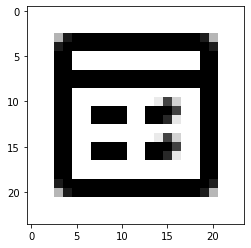

In [66]:
numbers = list(bytearray.fromhex(h[2:]))


image = PIL.Image.open(io.BytesIO(bytearray(numbers)))
imshow(np.asarray(image))

In [86]:
list(chunk(num, 64))

[(53, 23, 53, 64, 23, 6)]